# RideWise · Notebook 02 — Exploratory Data Analysis

**Understand trip economics, city and loyalty patterns, and what the churn landscape looks like before modelling.**

---

### What you will learn
- How to profile distributions that matter for a mobility business
- How surge, weather, payment and city interact with revenue
- How to read engagement from the sessions table
- How to frame EDA around the questions a model will later answer

### How to read this notebook
Every section follows the same rhythm used throughout the project:
**the business question first**, then the data, then the method, then a
**validation check** that proves the step did what we claimed. Run the cells
top to bottom; nothing depends on hidden state.

---

## 1. The business question

EDA is not a slideshow of every chart you can make. It answers: **which
behaviours vary between riders, and which of those might explain churn?**
We keep that lens throughout.

In [1]:
# --- environment setup (run me first) ---
import sys, os
from pathlib import Path

# Make the shared pipeline importable whether you launch from notebooks/ or root
ROOT = Path.cwd()
if (ROOT / "src").exists():
    SRC = ROOT / "src"
elif (ROOT.parent / "src").exists():
    SRC = ROOT.parent / "src"
else:
    raise FileNotFoundError("Could not locate the src/ folder with ridewise_pipeline.py")
sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print("Setup OK · pipeline module at:", SRC)

Setup OK · pipeline module at: /home/claude/ridewise/src


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
NAVY, ACCENT = "#1F3A5F", "#C8843C"

from ridewise_pipeline import load_raw, clean_trips, clean_riders
raw = load_raw()
trips = clean_trips(raw["trips"])
riders = clean_riders(raw["riders"])
sessions = raw["sessions"]
print("Loaded:", f"{len(trips):,} trips,", f"{len(riders):,} riders,", f"{len(sessions):,} sessions")

Loaded: 200,000 trips, 10,000 riders, 50,000 sessions


## 2. Trip economics: fare, surge and tips

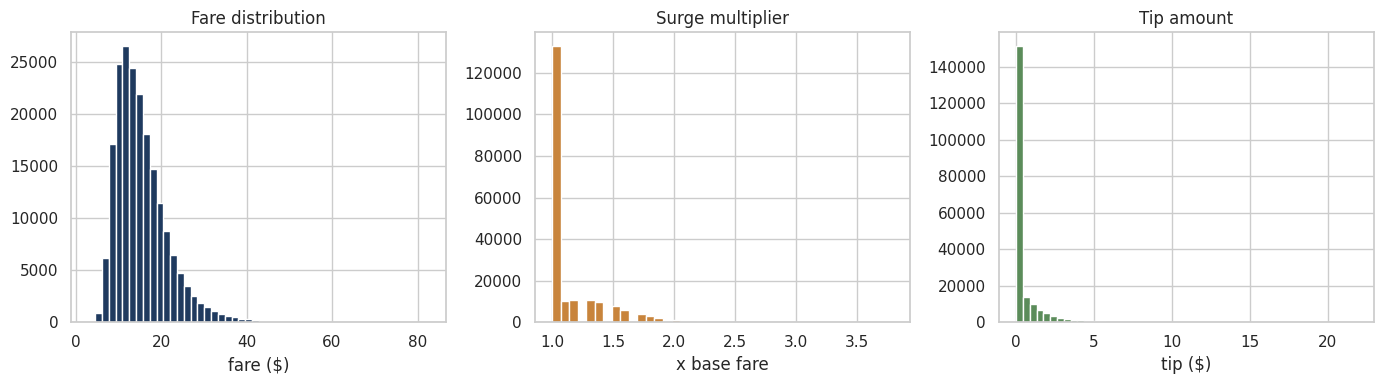

Median fare: $14.13
Share of trips with surge > 1.0: 33.6%
Share of trips with a tip: 34.3%


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].hist(trips["fare"], bins=50, color=NAVY); ax[0].set_title("Fare distribution"); ax[0].set_xlabel("fare ($)")
ax[1].hist(trips["surge_multiplier"], bins=40, color=ACCENT); ax[1].set_title("Surge multiplier"); ax[1].set_xlabel("x base fare")
ax[2].hist(trips["tip"], bins=50, color="#5B8C5A"); ax[2].set_title("Tip amount"); ax[2].set_xlabel("tip ($)")
plt.tight_layout(); plt.show()

print("Median fare: $%.2f" % trips["fare"].median())
print("Share of trips with surge > 1.0: %.1f%%" % ((trips["surge_multiplier"] > 1.0).mean() * 100))
print("Share of trips with a tip: %.1f%%" % ((trips["tip"] > 0).mean() * 100))

**Reading it:** most fares cluster in a tight band, surge is occasional but
real, and tipping is the exception not the rule. Surge exposure and tipping
behaviour are both candidate churn signals — frustrated, surged riders may
leave; generous tippers may be more committed.

## 3. City and loyalty structure

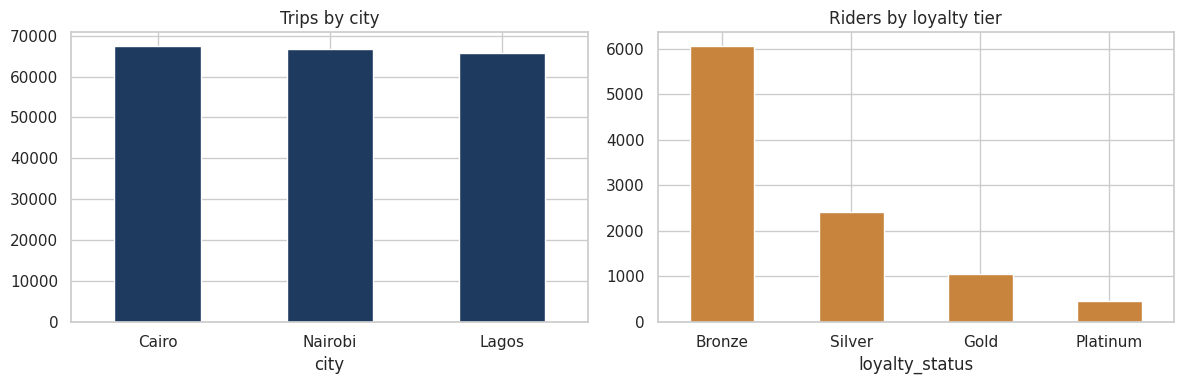

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
trips["city"].value_counts().plot.bar(ax=ax[0], color=NAVY); ax[0].set_title("Trips by city"); ax[0].tick_params(axis="x", rotation=0)
riders["loyalty_status"].value_counts().reindex(["Bronze","Silver","Gold","Platinum"]).plot.bar(ax=ax[1], color=ACCENT)
ax[1].set_title("Riders by loyalty tier"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 4. When do people ride? (temporal habits)

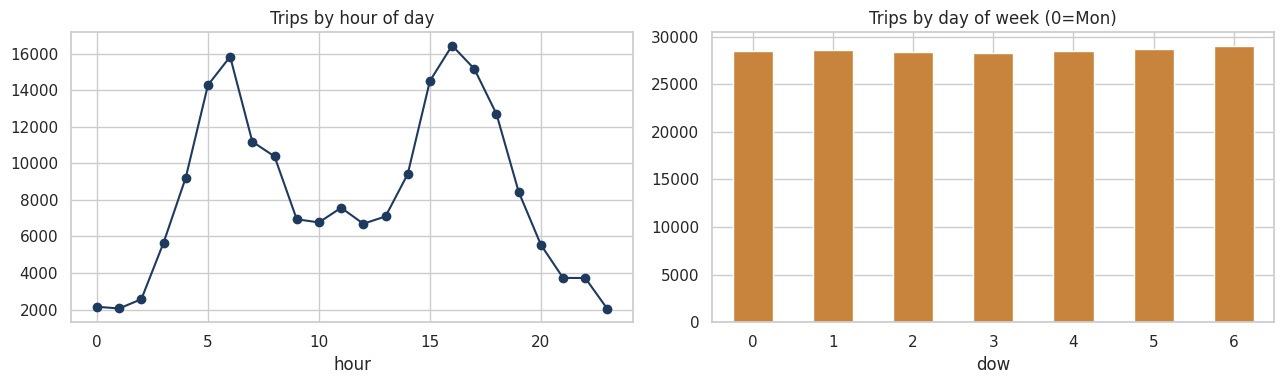

In [5]:
trips["hour"] = trips["pickup_time"].dt.hour
trips["dow"] = trips["pickup_time"].dt.dayofweek
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
trips["hour"].value_counts().sort_index().plot(ax=ax[0], color=NAVY, marker="o")
ax[0].set_title("Trips by hour of day"); ax[0].set_xlabel("hour")
trips.groupby("dow").size().plot.bar(ax=ax[1], color=ACCENT)
ax[1].set_title("Trips by day of week (0=Mon)"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Reading it:** the spread of riding hours and weekday/weekend balance differ
from rider to rider. We will turn these into `night_ratio` and `weekend_ratio`
features in Notebook 03, because *how* someone rides can separate a committed
commuter from a casual weekend user.

## 5. Engagement from sessions

Overall in-app conversion rate: 15.6%


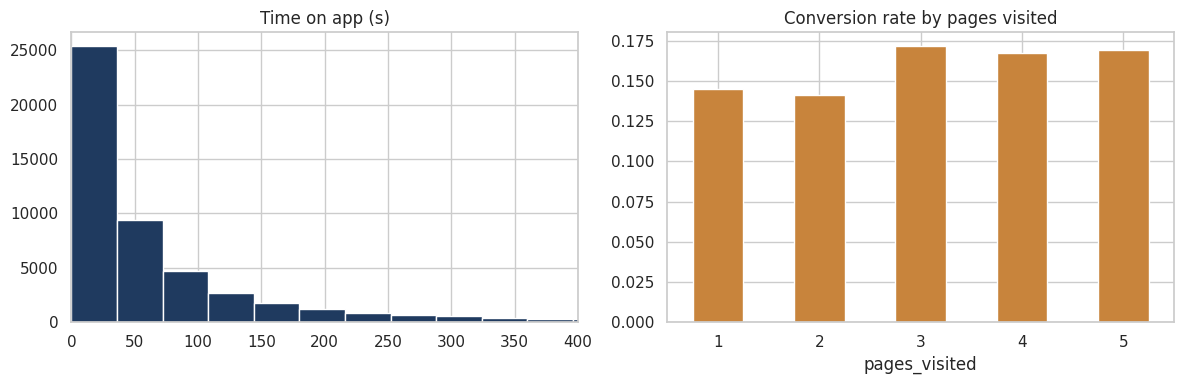

In [6]:
print("Overall in-app conversion rate: %.1f%%" % (sessions["converted"].mean() * 100))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sessions["time_on_app"], bins=50, color=NAVY); ax[0].set_title("Time on app (s)"); ax[0].set_xlim(0, 400)
sessions.groupby("pages_visited")["converted"].mean().plot.bar(ax=ax[1], color=ACCENT)
ax[1].set_title("Conversion rate by pages visited"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 6. Summary

- Fares are tight; surge and tipping are informative minorities.
- Three cities and four loyalty tiers give natural cohorts.
- Temporal and engagement behaviour vary across riders — the raw material for features.

**Next:** Notebook 03 turns all of this into one row per rider, and builds the churn label.